Analyze the distribution of reviews (e.g., positive, negative, neutral). Identify the most frequent words in reviews. Determine the average review length.




In [39]:
#libarary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import& Inspecting data

In [40]:
data=pd.read_csv('/content/restaurant_reviews.tsv',sep='\t')#read data
data.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


#Exploring Data

In [42]:
data.value_counts('Liked')# balnced data

,count
Liked,
0,500
1,500


<ipython-input-43-01398b87ea31>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Liked',data=data,palette='Set2')


<Axes: xlabel='Liked', ylabel='count'>

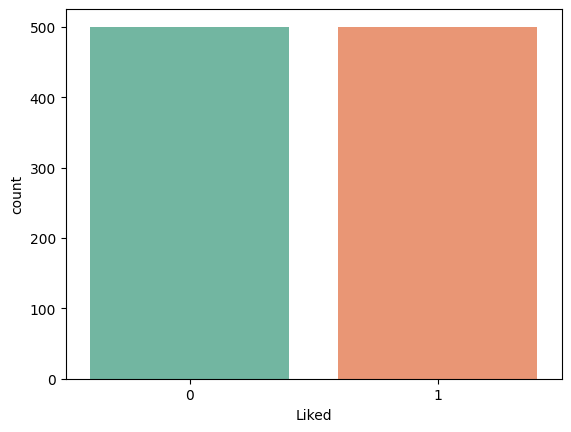

In [43]:
sns.countplot(x='Liked',data=data,palette='Set2')

<ipython-input-44-2e65a9f54342>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Liked'],color='red')


<Axes: xlabel='Liked', ylabel='Density'>

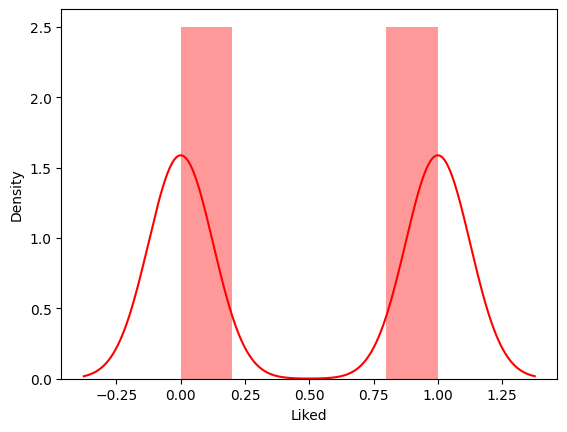

In [44]:
# Distribution plot for 'Liked'
sns.distplot(data['Liked'],color='red')

<Axes: ylabel='Liked'>

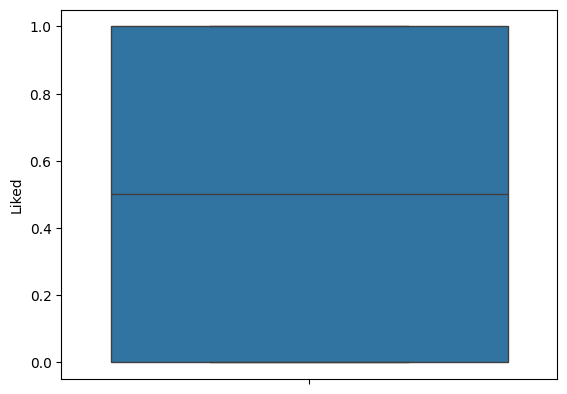

In [45]:
sns.boxplot(data['Liked'])

In [46]:
data["Review Letter Count"]=data["Review"].apply(len)
data

,Review,Liked,Review Letter Count
0,Wow... Loved this place.,1,24
1,Crust is not good.,0,18
2,Not tasty and the texture was just nasty.,0,41
3,Stopped by during the late May bank holiday of...,1,87
4,The selection on the menu was great and so wer...,1,59
...,...,...,...
995,I think food should have flavor and texture an...,0,66
996,Appetite instantly gone.,0,24
997,Overall I was not impressed and would not go b...,0,50
998,"The whole experience was underwhelming, and I ...",0,91


In [47]:
#display index one
data.iloc[0]

,0
Review,Wow... Loved this place.
Liked,1
Review Letter Count,24


In [48]:
#display max lengh review
data.iloc[data['Review Letter Count'].idxmax()]["Review"]

'The problem I have is that they charge $11.99 for a sandwich that is no bigger than a Subway sub (which offers better and more amount of vegetables).'

In [49]:
import nltk # Natural Language Toolkit

In [50]:
data['Review'][0]

'Wow... Loved this place.'

#pre-processing

In [51]:
import re # Regular Expression
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [52]:
# Create an empty list to store the processed reviews
corpus = []

# Initialize the Porter Stemmer for stemming words
ps = PorterStemmer()

# Iterate through each review in the DataFrame
for i in range(len(data)):
  # Remove non-alphabetic characters and replace with spaces
  review = re.sub('[^a-zA-Z]', ' ', data['Review'][i])

  # Convert the review to lowercase
  review = review.lower()

  # Split the review into individual words
  review = review.split()

  # Apply stemming and remove stop words
  review = [ps.stem(word) for word in review if not word in set(stopwords.words('english'))]

  # Join the processed words back into a single string
  review = ' '.join(review)

  # Add the processed review to the corpus list
  corpus.append(review)

In [53]:
corpus

['wow love place',
 'crust good',
 'tasti textur nasti',
 'stop late may bank holiday rick steve recommend love',
 'select menu great price',
 'get angri want damn pho',
 'honeslti tast fresh',
 'potato like rubber could tell made ahead time kept warmer',
 'fri great',
 'great touch',
 'servic prompt',
 'would go back',
 'cashier care ever say still end wayyy overpr',
 'tri cape cod ravoli chicken cranberri mmmm',
 'disgust pretti sure human hair',
 'shock sign indic cash',
 'highli recommend',
 'waitress littl slow servic',
 'place worth time let alon vega',
 'like',
 'burritto blah',
 'food amaz',
 'servic also cute',
 'could care less interior beauti',
 'perform',
 'right red velvet cake ohhh stuff good',
 'never brought salad ask',
 'hole wall great mexican street taco friendli staff',
 'took hour get food tabl restaur food luke warm sever run around like total overwhelm',
 'worst salmon sashimi',
 'also combo like burger fri beer decent deal',
 'like final blow',
 'found place acc

In [54]:
from sklearn.feature_extraction.text import CountVectorizer

In [55]:
cv=CountVectorizer()


In [56]:
x=cv.fit_transform(corpus).toarray()#convert data to numaric values

In [57]:
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [58]:
x.shape

(1000, 1565)

In [60]:
y=data['Liked']

In [61]:
y

,Liked
0,1
1,0
2,0
3,1
4,1
...,...
995,0
996,0
997,0
998,0


In [63]:
from sklearn.model_selection import train_test_split

In [64]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [65]:
x_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [66]:
y_train

,Liked
687,1
500,1
332,1
979,0
817,1
...,...
835,0
192,0
629,1
559,1


#Model Training

In [67]:
#Naive
from sklearn.naive_bayes import MultinomialNB

In [68]:
NB=MultinomialNB()

In [69]:
NB.fit(x_train,y_train)

MultinomialNB()

In [70]:
y_pred=NB.predict(x_test)

In [71]:
y_pred

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 1])

#Model Evaluation

In [72]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report


In [73]:
acc=accuracy_score(y_test,y_pred)

In [74]:
acc

0.765

              precision    recall  f1-score   support

           0       0.77      0.74      0.75        97
           1       0.76      0.79      0.78       103

    accuracy                           0.77       200
   macro avg       0.77      0.76      0.76       200
weighted avg       0.77      0.77      0.76       200



<Axes: >

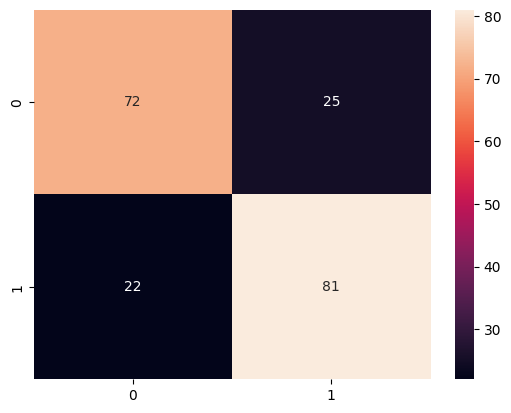

In [75]:
print(classification_report(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [76]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Define the vocabulary size and embedding dimension
vocab_size = 10000  # Adjust based on your data
embedding_dim = 128

# Create the RNN model
model = Sequential()
model.add(Embedding(vocab_size, embedding_dim))
model.add(SimpleRNN(128))  # Adjust the number of units as needed
model.add(Dense(1, activation='sigmoid'))  # For binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=10, batch_size=64)  # Adjust parameters as needed

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 237ms/step - accuracy: 0.4854 - loss: 0.6982
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.5158 - loss: 0.6979
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.4896 - loss: 0.6971
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.5061 - loss: 0.7050
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.4851 - loss: 0.6999
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.5126 - loss: 0.6917
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.4986 - loss: 0.6982
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.5084 - loss: 0.7058
Epoch 9/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.5470 - loss: 0.6894
Epoch 10/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.5060 - loss: 0.6916
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.5099 - loss: 0.7169
Test Loss: 0.7213816046714783
Test Accuracy: 0.5


In [78]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Define the vocabulary size and embedding dimension
vocab_size = 10000  # Adjust based on your data
embedding_dim = 128

# Create the LSTM model
model = Sequential()
model.add(Embedding(vocab_size, embedding_dim))
model.add(LSTM(128))  # Adjust the number of units as needed
model.add(Dense(1, activation='sigmoid'))  # For binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=100, batch_size=64)  # Adjust parameters as needed

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.4977 - loss: 0.6936
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.4765 - loss: 0.6935
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4760 - loss: 0.6933
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.5119 - loss: 0.6935
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5049 - loss: 0.6933
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4845 - loss: 0.6935
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5058 - loss: 0.6931
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.4867 - loss: 0.6936
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5099 - loss: 0.6931
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5053 - loss: 0.6930
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5077 - loss: 0.6931
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step

# Model Deployment

In [79]:
import joblib

In [80]:
joblib.dump(NB,"Restaurant_Review_Model.pkl")

['Restaurant_Review_Model.pkl']